# BreaKHis Evaluation and Error Analysis

## Objective
This notebook evaluates the selected corrected image model on the patient-level holdout set in more detail than a single accuracy number. The goal is to understand where the model succeeds, where it fails, and how trustworthy its probabilities appear.


In [1]:
from __future__ import annotations

import json
import random
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
plt.style.use('seaborn-v0_8-whitegrid')

CWD = Path.cwd().resolve()
if (CWD / 'src').exists() and (CWD / 'data').exists():
    PROJECT_ROOT = CWD
elif (CWD.parent / 'src').exists() and (CWD.parent / 'data').exists():
    PROJECT_ROOT = CWD.parent
elif (CWD.parent.parent / 'src').exists() and (CWD.parent.parent / 'data').exists():
    PROJECT_ROOT = CWD.parent.parent
else:
    raise RuntimeError(f'Could not resolve dissertation_project root from {CWD}')

REPO_ROOT = PROJECT_ROOT.parent
OUTPUTS = PROJECT_ROOT / 'outputs_v2'
FIGURES = OUTPUTS / 'figures'
METRICS = OUTPUTS / 'metrics'
REPORTS = OUTPUTS / 'reports'
MODELS = PROJECT_ROOT / 'models'
DATA_ROOT = PROJECT_ROOT / 'data' / 'dataset_cancer_v1' / 'dataset_cancer_v1'
WISCONSIN_ROOT = PROJECT_ROOT / 'notebook_Wisconsin'

for path in [FIGURES, METRICS, REPORTS]:
    path.mkdir(parents=True, exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print('Project root:', PROJECT_ROOT)
print('Outputs:', OUTPUTS)

from PIL import Image
from IPython.display import display

from src.breakhis import build_binary_records, patient_level_split
from src.image_pipeline import build_resnet18, predict_dataframe, resolve_device
from src.metrics import classification_metrics, expected_calibration_error, save_calibration_plot, save_confusion_matrix, save_metric_barplot, save_roc_curve

df = build_binary_records(DATA_ROOT)
split = patient_level_split(df, random_state=SEED)
device = resolve_device()
model = build_resnet18(device, weights=None, checkpoint_path=MODELS / 'breakhis_resnet18_patient_level_clean.pth')
full_test_predictions = predict_dataframe(model, split.test.reset_index(drop=True), batch_size=16, device=device)
full_test_predictions.to_csv(REPORTS / 'breakhis_full_test_predictions.csv', index=False)
full_test_predictions.head()


Project root: /Users/sergeysotskiy/Documents/UNI/year 3/Dissertation/dissertation_project
Outputs: /Users/sergeysotskiy/Documents/UNI/year 3/Dissertation/dissertation_project/outputs_v2


,filepath,patient_id,label,magnification,y_true,y_pred,y_prob
0,/Users/sergeysotskiy/Documents/UNI/year 3/Diss...,SOB_B_F-14-21998CD,benign,100X,0,0,0.286750
1,/Users/sergeysotskiy/Documents/UNI/year 3/Diss...,SOB_B_F-14-21998CD,benign,100X,0,0,0.176840
2,/Users/sergeysotskiy/Documents/UNI/year 3/Diss...,SOB_B_F-14-21998CD,benign,100X,0,0,0.193582
3,/Users/sergeysotskiy/Documents/UNI/year 3/Diss...,SOB_B_F-14-21998CD,benign,100X,0,0,0.207730
4,/Users/sergeysotskiy/Documents/UNI/year 3/Diss...,SOB_B_F-14-21998CD,benign,100X,0,0,0.207240


In [2]:
image_metrics = classification_metrics(full_test_predictions['y_true'], full_test_predictions['y_pred'], full_test_predictions['y_prob'])
image_metrics['ece'] = expected_calibration_error(full_test_predictions['y_true'], full_test_predictions['y_prob'])
image_metrics_df = pd.DataFrame([image_metrics])
image_metrics_df.to_csv(METRICS / 'breakhis_image_level_metrics.csv', index=False)
image_metrics_df


,accuracy,precision,recall,f1_score,roc_auc,brier_score,ece
0,0.774532,0.721081,0.939437,0.815902,0.891707,0.165944,0.165139


In [3]:
patient_predictions = (
    full_test_predictions.groupby(['patient_id', 'label'])['y_prob']
    .mean()
    .reset_index()
)
patient_predictions['y_true'] = (patient_predictions['label'] == 'malignant').astype(int)
patient_predictions['y_pred'] = (patient_predictions['y_prob'] >= 0.5).astype(int)
patient_metrics = classification_metrics(patient_predictions['y_true'], patient_predictions['y_pred'], patient_predictions['y_prob'])
patient_metrics['ece'] = expected_calibration_error(patient_predictions['y_true'], patient_predictions['y_prob'])
patient_metrics_df = pd.DataFrame([patient_metrics])
patient_metrics_df.to_csv(METRICS / 'breakhis_patient_level_metrics.csv', index=False)
patient_predictions.to_csv(REPORTS / 'breakhis_patient_level_predictions.csv', index=False)
patient_metrics_df


,accuracy,precision,recall,f1_score,roc_auc,brier_score,ece
0,0.769231,0.8,0.888889,0.842105,0.916667,0.117235,0.230616


In [4]:
magnification_metrics = []
for magnification, frame in full_test_predictions.groupby('magnification'):
    metrics = classification_metrics(frame['y_true'], frame['y_pred'], frame['y_prob'])
    metrics['magnification'] = magnification
    magnification_metrics.append(metrics)
magnification_metrics_df = pd.DataFrame(magnification_metrics).sort_values('magnification')
magnification_metrics_df.to_csv(METRICS / 'breakhis_magnification_metrics.csv', index=False)
magnification_metrics_df


,accuracy,precision,recall,f1_score,roc_auc,brier_score,magnification
0,0.772080,0.716599,0.946524,0.815668,0.911928,0.153776,100X
1,0.805970,0.746835,0.972527,0.844869,0.932953,0.150781,200X
2,0.768212,0.725888,0.899371,0.803371,0.850112,0.174424,400X
3,0.752161,0.696721,0.934066,0.798122,0.871628,0.185510,40X


In [5]:
save_confusion_matrix(patient_predictions['y_true'], patient_predictions['y_pred'], ['benign', 'malignant'], FIGURES / 'breakhis_patient_confusion_matrix.png', 'Patient-level confusion matrix')
save_roc_curve(patient_predictions['y_true'], patient_predictions['y_prob'], FIGURES / 'breakhis_patient_roc_curve.png', 'Patient-level ROC curve')
save_calibration_plot(patient_predictions['y_true'], patient_predictions['y_prob'], FIGURES / 'breakhis_patient_calibration.png', 'Patient-level calibration curve')
save_metric_barplot(
    magnification_metrics_df[['magnification', 'roc_auc']],
    x='magnification',
    y='roc_auc',
    hue=None,
    output_path=FIGURES / 'breakhis_magnification_roc_auc.png',
    title='ROC-AUC by magnification on the corrected test set',
    ylabel='ROC-AUC',
)


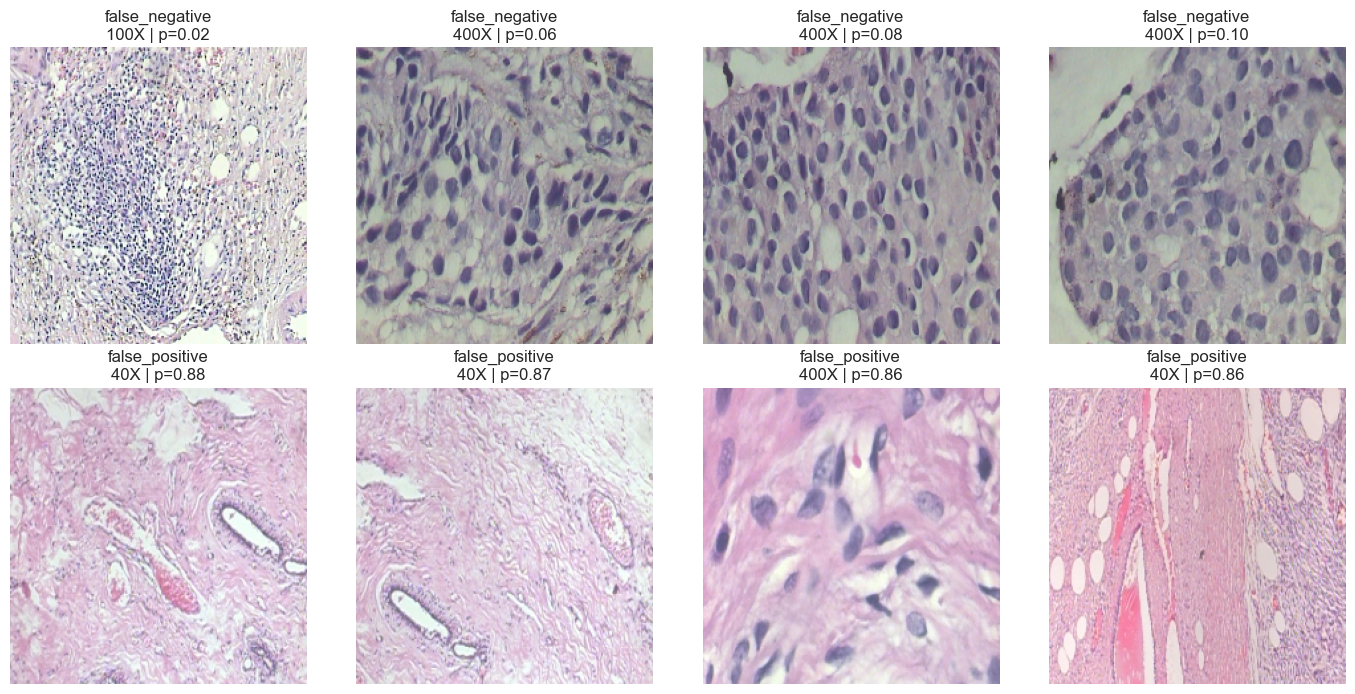

In [6]:
false_negatives = full_test_predictions[(full_test_predictions['y_true'] == 1) & (full_test_predictions['y_pred'] == 0)].sort_values('y_prob').head(4)
false_positives = full_test_predictions[(full_test_predictions['y_true'] == 0) & (full_test_predictions['y_pred'] == 1)].sort_values('y_prob', ascending=False).head(4)
error_panel = pd.concat([false_negatives.assign(error_type='false_negative'), false_positives.assign(error_type='false_positive')], ignore_index=True)
error_panel.to_csv(REPORTS / 'breakhis_error_examples.csv', index=False)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, (_, row) in zip(axes.ravel(), error_panel.iterrows()):
    with Image.open(row['filepath']) as image:
        ax.imshow(image.convert('RGB'))
    ax.set_title(f"{row['error_type']}\n{row['magnification']} | p={row['y_prob']:.2f}")
    ax.axis('off')
fig.tight_layout()
fig.savefig(FIGURES / 'breakhis_error_panel.png', dpi=300)
plt.show()


## Interpretation

The corrected patient-level evaluation is the dissertation's main image result. It is lower than the earlier leaked result, but it is far more defendable. The magnification-level breakdown and explicit error review also give the later discussion chapter something substantial to analyse beyond a single aggregate metric.
